In [2]:
import torch
import torch.nn as nn


# Das Netz
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

# Warum tanh und nicht ReLU?
# Tanh wählt die Werte zwischen -1 und 1 und bei Relu alle Y-Werte die unter null sind haben auch x-wert null. 
# # Und bei relu ich denke die Ableitung könnte kritisch sein.

# Warum tanh — die präzise Antwort

Du erinnerst dich: Der **Physics-Loss** braucht $\frac{d^2u}{dx^2}$.  
Das bedeutet: du differenzierst das Netz zweimal nach den Eingaben.

### ReLU hat ein kritisches Problem dabei:
* **ReLU:** $f(x) = \max(0, x)$
* **Erste Ableitung:** $0$ oder $1$ — stückweise konstant
* **Zweite Ableitung:** **überall 0**

Wenn $\frac{d^2u}{dx^2}$ immer null ist — ist dein **Physics-Loss blind**. Er sieht keine Krümmung. Das Netz kann die Wärmeleitungsgleichung nicht lernen.

---

### tanh funktioniert weil:
* **Erste Ableitung:** $1 - \tanh^2(x)$ — glatt und nicht null
* **Zweite Ableitung:** existiert und ist aussagekräftig

**Das Netz kann echte Krümmung modellieren.**

In [3]:
# Die Ableitungen
def physics_loss(model, x, t, alpha=0.01):
    x = x.requires_grad_(True) # merke dir den Graphen bezüglich dieser Eingabe — nicht nur der Gewichte.
    t = t.requires_grad_(True)
    
    u = model(x, t)
    
    # du/dt
    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    
    # du/dx
    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    
    # d²u/dx²
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]
    
    residual = u_t - alpha * u_xx
    return torch.mean(residual**2)

In [4]:
# Die Randbedingungen
def boundary_loss(model):
    # Anfangsbedingung: u(x, 0) = sin(πx)
    x_ic = torch.linspace(0, 1, 100).reshape(-1, 1)
    t_ic = torch.zeros_like(x_ic)
    u_ic = model(x_ic, t_ic)
    u_ic_true = torch.sin(torch.pi * x_ic)
    loss_ic = torch.mean((u_ic - u_ic_true)**2)
    
    # Randbedingung: u(0,t) = u(1,t) = 0
    t_bc = torch.linspace(0, 1, 100).reshape(-1, 1)
    x_left = torch.zeros_like(t_bc)
    x_right = torch.ones_like(t_bc)
    
    loss_bc = torch.mean(model(x_left, t_bc)**2) + \
              torch.mean(model(x_right, t_bc)**2)
    
    return loss_ic + loss_bc

In [5]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Kollokationspunkte
N = 1000
x_col = torch.rand(N, 1)
t_col = torch.rand(N, 1)

for epoch in range(5000):
    optimizer.zero_grad()
    
    lp = physics_loss(model, x_col, t_col)
    lb = boundary_loss(model)
    
    loss = lb + 0.1 * lp  # λ = 0.1
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Total: {loss.item():.5f} | Physics: {lp.item():.5f} | Boundary: {lb.item():.5f}")

Epoch 0 | Total: 0.66916 | Physics: 0.02091 | Boundary: 0.66707
Epoch 500 | Total: 0.00153 | Physics: 0.00655 | Boundary: 0.00088
Epoch 1000 | Total: 0.00033 | Physics: 0.00136 | Boundary: 0.00020
Epoch 1500 | Total: 0.00011 | Physics: 0.00049 | Boundary: 0.00006
Epoch 2000 | Total: 0.00007 | Physics: 0.00033 | Boundary: 0.00004
Epoch 2500 | Total: 0.00005 | Physics: 0.00023 | Boundary: 0.00003
Epoch 3000 | Total: 0.00003 | Physics: 0.00015 | Boundary: 0.00002
Epoch 3500 | Total: 0.00002 | Physics: 0.00009 | Boundary: 0.00001
Epoch 4000 | Total: 0.00001 | Physics: 0.00005 | Boundary: 0.00001
Epoch 4500 | Total: 0.00001 | Physics: 0.00003 | Boundary: 0.00000


Physics Loss war am Anfang klein — nicht weil das Netz die Physik kannte, sondern weil ein fast-null Netz automatisch die Differentialgleichung fast erfüllt. Echtes Lernen passiert erst wenn Boundary Loss sinkt und das Netz gezwungen wird, eine echte Struktur zu lernen.



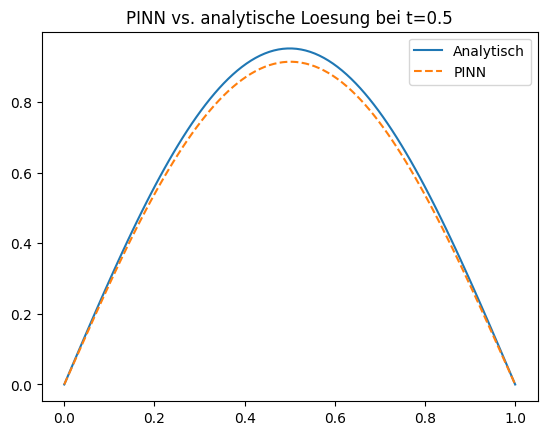

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x_test = torch.linspace(0, 1, 100).reshape(-1, 1)
t_test = torch.full_like(x_test, 0.9)  # bei t=0.5

with torch.no_grad():
    u_pred = model(x_test, t_test).numpy()

u_true = np.exp(-0.01 * np.pi**2 * 0.5) * np.sin(np.pi * x_test.numpy())

plt.plot(x_test.numpy(), u_true, label="Analytisch")
plt.plot(x_test.numpy(), u_pred, '--', label="PINN")
plt.legend()
plt.title("PINN vs. analytische Loesung bei t=0.5")
plt.show()